In [2]:
import pandas as pd
import tiktoken

import pickle

from tqdm.notebook import tqdm

import os

from IPython.display import display, Markdown

import json

from pythonjsonlogger.json import JsonFormatter

from adr import adr

from typing import Literal, Dict, List, Tuple

from enum import Enum

import logging
import sys
import numpy as np

from sentence_transformers import SentenceTransformer


from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import MultiLabelBinarizer, LabelEncoder
from sklearn.model_selection import train_test_split

from catboost import CatBoostClassifier

import seaborn as sns # Optional: for a visual heatmap
import matplotlib.pyplot as plt # Optional: for plotting

from sklearn.metrics import precision_recall_fscore_support
from sklearn.metrics import accuracy_score
from sklearn.utils.class_weight import compute_class_weight


In [3]:
ENGLISH_DATAPATH = './data/LLM4ADR-adrs__adrs_english.pickle'

relative_path = os.path.join('..', ENGLISH_DATAPATH)
with open(relative_path,'rb') as file_handle:
    dict_adrs = pickle.load(file_handle)
print(len(dict_adrs), "projects/organizations?")


547 projects/organizations?


In [4]:
# GROUND_TRUTH_DATAPATH = './sample/kruchten_gt_processed.csv'
# GROUND_TRUTH_DATAPATH = './sample/qas_gt_processed.csv'
GROUND_TRUTH_DATAPATH = './sample/zimmermann_gt_processed.csv'

relative_path = os.path.join('..', GROUND_TRUTH_DATAPATH)
df_gt = pd.read_csv(relative_path, sep=';').dropna(subset=['text', 'human', 'ADR'])
print(df_gt.shape)
print(len(df_gt['human'].unique()), df_gt['human'].unique())
print(len(df_gt['primary_category'].unique()), df_gt['primary_category'].unique())

df_gt.head()

(200, 8)
8 ['Design' 'Infrastructure' 'Technology' 'Implementation'
 'Crosscutting Concerns' 'Constraint' 'Organizational/Process' 'Other']
8 ['Design' 'Infrastructure' 'Technology' 'Constraint' 'Other'
 'Crosscutting Concerns' 'Implementation' 'Organizational/Process']


,text,ADR,Organization-Project,primary_category,explanation,max_confidence_value,human,Agreement
0,'adr 3: connecting the store to a component pw...,adr-003-store-connector-container-component.md,"('AYCHAIN', 'AYCHAIN.github.io')",Design,The ADR primarily discusses the architectural ...,"0,85",Design,1.0
1,'4. compute provisioning through ansible Accep...,adr-004.md,"('Abelaa', 'pcmt')",Infrastructure,The ADR focuses on provisioning and deployment...,"0,70",Infrastructure,1.0
2,"'7. versioning and release mechanism Accepted,...",adr-007.md,"('Abelaa', 'pcmt')",Technology,The ADR focuses on establishing a versioning a...,"0,75",Technology,1.0
3,"'3. for config, prefer prefix over nesting and...",0003-for-config-prefer-prefix-over-nesting-and...,"('Accenture', 'reactive-interaction-gateway')",Design,The ADR primarily addresses the organization a...,"0,85",Infrastructure,0.0
4,'cutting release branch does not create a set ...,005-cutting-release-branch.md,"('Accenture', 'sfpowerscripts')",Technology,The ADR primarily discusses changes to the rel...,"0,60",Technology,1.0


In [5]:
logger = logging.getLogger(__name__)
logger.setLevel(logging.WARNING)

formatter = JsonFormatter(fmt='%(asctime)s %(levelname)s %(name)s %(message)s')
logHandler = logging.StreamHandler(sys.stdout)
logHandler.setFormatter(formatter)
logger.addHandler(logHandler)

In [6]:
def get_documents(org_projects: Tuple[str, str, str], adrs_dict: Dict, field='both', verbose=False):
    # Extract documents from the ADRs based on the specified field
    docs = {} # []
    for org, project in org_projects:
        if verbose:
            logger.info("===", org, project)  # Added print statement for verbose output
        adrs = adrs_dict[org][project]
        for adr in adrs.keys():
            if verbose:
                logger.info(adr)
            doc=""
            if field == 'content':
                doc = adrs[adr].get_content_no_code_str()
            elif field == 'title':
                doc = adrs[adr].get_title()
            elif field == 'both':
                doc = adrs[adr].get_title() + " " + adrs[adr].get_content_no_code_str()
            elif field == 'raw':
                doc = adrs[adr].get_full_raw_content()
            elif field == 'decision':
                doc = "* ADR Title: " + adrs[adr].get_title() + '\n' + \
                      "* ADR Decision: " + adrs[adr].get_decision()
            if verbose:
                logger.info(doc)
            docs[(org, project, adr)] = doc
    if verbose:
        logger.info("===")
    return docs

def get_documents_by_key(org_project: Tuple[str, str, str], adrs_dict: Dict, field='content', verbose=False) -> Dict[str, str]:
    docs = get_documents([org_project], adrs_dict, field=field, verbose=verbose)
    return {adr: docs[(org, project, adr)] for org, project, adr in docs}

def process_projects(dict_adrs: Dict, min_adrs_per_project: int = 5, min_adr_length: int = 500):
    # Check projects and ADRs and filter out those that do not have enough ADRs or ADRs that are too short
    valid_projects = set()
    filtered_projects = set()
    all_projects = set()
    for org in tqdm(dict_adrs, "organizations"): 
        for project in dict_adrs[org]:
            all_projects.add((org, project))
            # print(dict_adrs[org][project].keys())
            if len(dict_adrs[org][project]) < min_adrs_per_project:
                filtered_projects.add((org, project))
                continue
            valid = 0
            for adr_ in dict_adrs[org][project]: # TODO: Queremos que tenga más de 5 adrs con 500 chars o las dos condiciones se evalúan por separado?
                s = dict_adrs[org][project][adr_].get_content_no_code_str()
                if (len(s) >= min_adr_length) and not s.isspace() :
                    valid += 1
            if valid < min_adrs_per_project:
                filtered_projects.add((org, project))
                continue
            # print("Valid project: ", org, project)
            valid_projects.add((org, project))
    
    logger.info("all orgs+projects: ", len(all_projects))
    logger.info("filtered projects: ", len(filtered_projects))
    logger.info("valid projects: ", len(valid_projects))
    return {
        "all_projects": list(all_projects),
        "filtered_projects": list(filtered_projects),
        "valid_projects": list(valid_projects)
    }


In [7]:
projects_dict = process_projects(dict_adrs, min_adrs_per_project=5, min_adr_length=500)
valid_projects = projects_dict['valid_projects']

docs = get_documents(valid_projects, dict_adrs, field='raw')
print(len(docs), "ADRs considered within valid projects")

organizations:   0%|          | 0/547 [00:00<?, ?it/s]

4316 ADRs considered within valid projects


In [8]:
class ZimmermannEnum(str, Enum):
    DESIGN_DECISION = "Design"
    TECHNOLOGY_DECISION = "Technology"
    INFRASTRUCTURE_DECISION = "Infrastructure"
    ORGANIZATIONAL_PROCESS_DECISION = "Organizational/Process"
    CONSTRAINT = "Constraint"
    QUALITY_ATTRIBUTE_DECISION = "Quality Attribute"
    CROSSCUTTING_CONCERNS_DECISION = "Crosscutting Concerns"
    IMPLEMENTATION = "Implementation"
    OTHER = "Other"

In [9]:
[str(member.value) for member in ZimmermannEnum]

['Design',
 'Technology',
 'Infrastructure',
 'Organizational/Process',
 'Constraint',
 'Quality Attribute',
 'Crosscutting Concerns',
 'Implementation',
 'Other']

In [10]:
model = SentenceTransformer('all-MiniLM-L6-v2')

In [11]:
# Convert the column to a list of strings
sentences = df_gt['text'].tolist()

# Generate embeddings (numpy array)
embeddings = model.encode(sentences)

labels = [str(member.value) for member in ZimmermannEnum]
le = LabelEncoder()
encoding = le.fit_transform(labels)
target = le.transform(df_gt['human'].values)

embeddings_df = pd.DataFrame(embeddings)
print(embeddings_df.shape)
embeddings_df['target'] = target
embeddings_df

(200, 384)


,0,1,2,3,4,5,6,7,8,9,...,375,376,377,378,379,380,381,382,383,target
0,-0.104636,-0.010884,-0.031404,0.062119,-0.013692,0.031265,-0.003519,0.017488,0.002491,-0.003342,...,0.026065,-0.057296,-0.004504,0.055123,-0.005405,0.020220,0.017851,0.028315,0.019486,2
1,-0.015436,0.004884,0.058292,-0.023401,-0.043252,-0.025533,-0.096268,-0.032399,-0.016986,0.045593,...,0.074023,-0.059269,0.068218,0.101712,-0.012285,0.009272,0.002622,0.008328,-0.083203,4
2,-0.029634,0.066878,0.069833,-0.049863,0.032478,-0.018663,-0.022288,-0.026553,0.007844,0.053356,...,0.088667,-0.034559,0.027010,0.084534,0.006160,0.075046,-0.028905,0.064031,0.037997,8
3,-0.107723,0.036838,-0.050998,0.012439,-0.038145,-0.048607,-0.003588,0.064621,-0.036761,0.002060,...,0.015607,-0.003862,0.025176,0.059083,-0.014387,-0.042914,-0.035619,-0.091091,0.009868,4
4,-0.010696,-0.013149,0.044928,-0.048865,0.047021,-0.058640,-0.062020,0.029060,-0.039175,0.086975,...,0.074510,-0.002867,-0.026637,0.070180,-0.006650,0.011874,-0.051745,0.116802,-0.028449,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,-0.056350,-0.028498,-0.001530,-0.067554,-0.071970,-0.063822,-0.095268,-0.063177,0.060727,-0.032513,...,0.029545,-0.035083,-0.012389,0.085267,0.050889,0.118528,-0.038301,-0.014090,-0.000961,2
196,-0.020899,-0.002797,-0.017669,-0.021651,0.020991,-0.006008,-0.047673,-0.058135,0.028473,-0.022879,...,0.111060,-0.008828,0.012580,0.089099,-0.003912,0.106626,0.004977,0.082804,-0.053118,8
197,-0.033112,0.035546,-0.002878,-0.052808,0.061835,-0.048014,-0.009350,-0.070519,0.038664,-0.038667,...,0.018312,0.000227,0.056515,0.095949,-0.033656,0.071736,-0.036701,0.102772,0.002818,2
198,-0.008141,0.005428,-0.009096,-0.025956,0.105896,-0.039108,0.014975,0.009707,-0.034470,0.012017,...,0.093113,-0.028205,-0.118665,0.100338,0.067014,-0.021668,-0.010053,-0.022795,-0.024615,2


In [12]:
X = embeddings_df.drop(columns=['target'])
y = embeddings_df['target']

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Assuming X_train, y_train are your training data and labels
classes = np.unique(y_train)
weights = compute_class_weight(
    class_weight='balanced', 
    classes=classes, 
    y=y_train
)

class_weights_dict = dict(zip(classes, weights))

In [14]:
classifier = CatBoostClassifier(iterations=1000, loss_function='MultiClass',  class_weights=class_weights_dict, verbose=False)
classifier.fit(X_train, y_train)

y_pred = classifier.predict(X_test)
y_true = y_test

In [15]:
actual_labels = list(set(le.inverse_transform(y)))
report = classification_report(y_true, y_pred, target_names=actual_labels, output_dict=True)
cm = confusion_matrix(y_true, y_pred)
cm_df = pd.DataFrame(cm, index=actual_labels, columns=actual_labels)

/Users/adiazpace/opt/anaconda3/envs/adrs/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/adiazpace/opt/anaconda3/envs/adrs/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/adiazpace/opt/anaconda3/envs/adrs/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f

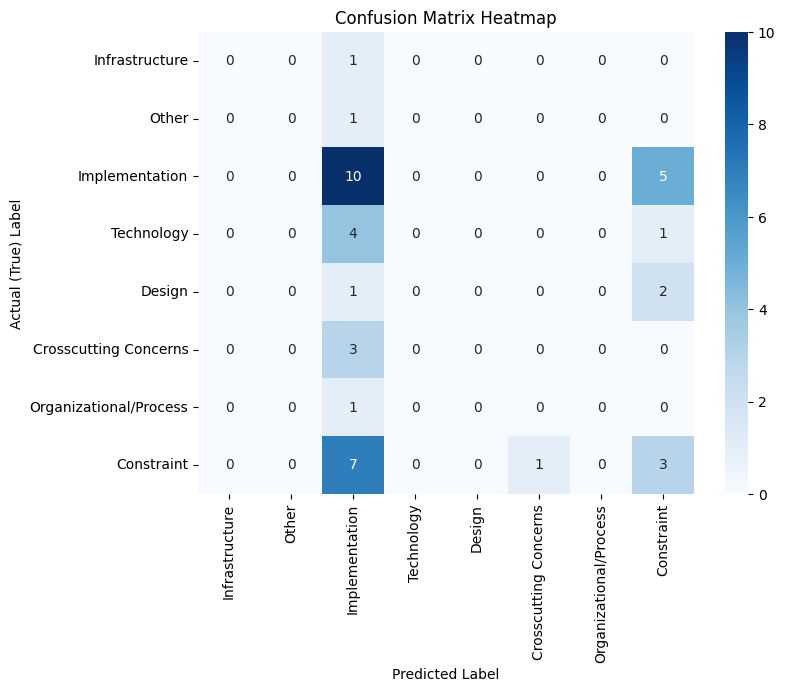

In [16]:
# Plot the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix Heatmap')
plt.ylabel('Actual (True) Label')
plt.xlabel('Predicted Label')
plt.show()

In [32]:
report

{'Technology': {'precision': 0.0,
  'recall': 0.0,
  'f1-score': 0.0,
  'support': 1.0},
 'Organizational/Process': {'precision': 0.0,
  'recall': 0.0,
  'f1-score': 0.0,
  'support': 1.0},
 'Design': {'precision': 0.42424242424242425,
  'recall': 0.9333333333333333,
  'f1-score': 0.5833333333333334,
  'support': 15.0},
 'Crosscutting Concerns': {'precision': 0.0,
  'recall': 0.0,
  'f1-score': 0.0,
  'support': 5.0},
 'Implementation': {'precision': 0.0,
  'recall': 0.0,
  'f1-score': 0.0,
  'support': 3.0},
 'Other': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 3.0},
 'Infrastructure': {'precision': 0.0,
  'recall': 0.0,
  'f1-score': 0.0,
  'support': 1.0},
 'Constraint': {'precision': 0.42857142857142855,
  'recall': 0.2727272727272727,
  'f1-score': 0.3333333333333333,
  'support': 11.0},
 'accuracy': 0.425,
 'macro avg': {'precision': 0.1066017316017316,
  'recall': 0.15075757575757576,
  'f1-score': 0.11458333333333334,
  'support': 40.0},
 'weighted avg': {'pre

In [34]:
precision, recall, fscore, support = precision_recall_fscore_support(y_true, y_pred, average=None)

print("Metrics per class:")
print(f"  Precision: {precision}")
print(f"  Recall:    {recall}")
print(f"  F-measure: {fscore}")
print(f"  Support:   {support}\n")

# 3. Compute overall metrics using different averaging methods

# Macro average: calculates metrics for each label and finds their unweighted mean. 
# This does not take label imbalance into account.
macro_precision, macro_recall, macro_fscore, _ = precision_recall_fscore_support(y_true, y_pred, average='macro')

print("Overall (Macro) Metrics:")
print(f"  Precision: {macro_precision:.4f}")
print(f"  Recall:    {macro_recall:.4f}")
print(f"  F-measure: {macro_fscore:.4f}\n")

# Weighted average: calculates metrics for each label and finds their average 
# weighted by support (the number of true instances for each label).
weighted_precision, weighted_recall, weighted_fscore, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')

print("Overall (Weighted) Metrics:")
print(f"  Precision: {weighted_precision:.4f}")
print(f"  Recall:    {weighted_recall:.4f}")
print(f"  F-measure: {weighted_fscore:.4f}\n")

# Micro average: calculates metrics globally by counting the total true positives, 
# false negatives, and false positives. Useful for multi-label problems.
micro_precision, micro_recall, micro_fscore, _ = precision_recall_fscore_support(y_true, y_pred, average='micro')

print("Overall (Micro) Metrics:")
print(f"  Precision: {micro_precision:.4f}")
print(f"  Recall:    {micro_recall:.4f}")
print(f"  F-measure: {micro_fscore:.4f}")

# Note: Micro precision, recall, and f-measure are all equal to overall accuracy.
print(f"  Overall Accuracy: {accuracy_score(y_true, y_pred):.4f}")


Metrics per class:
  Precision: [0.         0.         0.42424242 0.         0.         0.
 0.         0.42857143]
  Recall:    [0.         0.         0.93333333 0.         0.         0.
 0.         0.27272727]
  F-measure: [0.         0.         0.58333333 0.         0.         0.
 0.         0.33333333]
  Support:   [ 1  1 15  5  3  3  1 11]

Overall (Macro) Metrics:
  Precision: 0.1066
  Recall:    0.1508
  F-measure: 0.1146

Overall (Weighted) Metrics:
  Precision: 0.2769
  Recall:    0.4250
  F-measure: 0.3104

Overall (Micro) Metrics:
  Precision: 0.4250
  Recall:    0.4250
  F-measure: 0.4250
  Overall Accuracy: 0.4250


/Users/adiazpace/opt/anaconda3/envs/adrs/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/adiazpace/opt/anaconda3/envs/adrs/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/adiazpace/opt/anaconda3/envs/adrs/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f